# Notebook 3 — CNN Classification (4-class)

Trains a lightweight CNN on Raw, GHE, and CLAHE datasets. Multiclass softmax output.

In [1]:
import random, numpy as np, pandas as pd, tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report)
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); tf.random.set_seed(RANDOM_STATE)

PROJECT_DIR   = Path.cwd().parent
PROCESSED_DIR = PROJECT_DIR / "outputs" / "processed_v2_binary"
RESULTS_DIR   = PROJECT_DIR / "outputs" / "results_v2_binary"
FIGURES_DIR   = PROJECT_DIR / "outputs" / "figures_v2_binary"
MODELS_DIR    = PROJECT_DIR / "outputs" / "models_v2_binary"
for d in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR]: d.mkdir(parents=True, exist_ok=True)

CLASSES = ["no_tumor", "tumor"]
EPOCHS  = 30
BATCH   = 32

In [2]:
methods = ["raw", "ghe", "clahe"]
datasets = {}
for m in methods:
    d = np.load(PROCESSED_DIR / f"{m}_binary_data.npz")
    datasets[m] = {k: d[k] for k in ["X_train","y_train","X_val","y_val","X_test","y_test"]}
    print(f"{m.upper()}: train={d['X_train'].shape}, val={d['X_val'].shape}, test={d['X_test'].shape}")

RAW: train=(4760, 128, 128, 1), val=(840, 128, 128, 1), test=(1600, 128, 128, 1)
GHE: train=(4760, 128, 128, 1), val=(840, 128, 128, 1), test=(1600, 128, 128, 1)
CLAHE: train=(4760, 128, 128, 1), val=(840, 128, 128, 1), test=(1600, 128, 128, 1)


In [3]:
def build_cnn(input_shape=(128, 128, 1)):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        
        layers.Dense(1, activation="sigmoid")
    ])
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

build_cnn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 453,889 (1.73 MB)

 Trainable params: 453,889 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def get_class_weights(y):
    classes = np.unique(y)
    
    w = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y
    )
    
    return dict(zip(classes, w))


def calc_metrics(y_true, y_prob):
    y_prob = y_prob.ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    
    auc = roc_auc_score(y_true, y_prob)
    
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1_score":  f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   auc,
    }, y_pred

In [5]:
def plot_history(history, method):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, ylabel in zip(axes, ["accuracy","loss"], ["Accuracy","Loss"]):
        ax.plot(history.history[metric], label="Train")
        ax.plot(history.history[f"val_{metric}"], label="Val")
        ax.set_title(f"CNN {ylabel} — {method.upper()}"); ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel); ax.legend(); ax.grid(True)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"v2_cnn_{method}_history.png", dpi=150)
    plt.show()

def plot_cm(y_true, y_pred, method):
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(5, 5))
    
    ConfusionMatrixDisplay(
        cm,
        display_labels=CLASSES
    ).plot(ax=ax, values_format="d", colorbar=False)
    
    plt.title(f"CNN Confusion Matrix — {method.upper()}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"v2_binary_cnn_{method}_confusion_matrix.png", dpi=150)
    plt.show()

Training CNN on RAW

Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 54s 327ms/step - accuracy: 0.7462 - auc: 0.8663 - loss: 0.4564 - precision: 0.9230 - recall: 0.7218 - val_accuracy: 0.9214 - val_auc: 0.9379 - val_loss: 0.2529 - val_precision: 0.9338 - val_recall: 0.9635
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 48s 322ms/step - accuracy: 0.9034 - auc: 0.9457 - loss: 0.2934 - precision: 0.9466 - recall: 0.9232 - val_accuracy: 0.9250 - val_auc: 0.9628 - val_loss: 0.2425 - val_precision: 0.9640 - val_recall: 0.9349
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 48s 325ms/step - accuracy: 0.9267 - auc: 0.9704 - loss: 0.2200 - precision: 0.9702 - recall: 0.9308 - val_accuracy: 0.9464 - val_auc: 0.9783 - val_loss: 0.1600 - val_precision: 0.9695 - val_recall: 0.9587
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 48s 325ms/step - accuracy: 0.9334 - auc: 0.9769 - loss: 0.1849 - precision: 0.9799 - recall: 0.9303 - val_accuracy: 0.9452 - val_auc: 0.9821 - val_loss: 0.1565 - val_precision: 0.9803 - val_recall: 0.9460

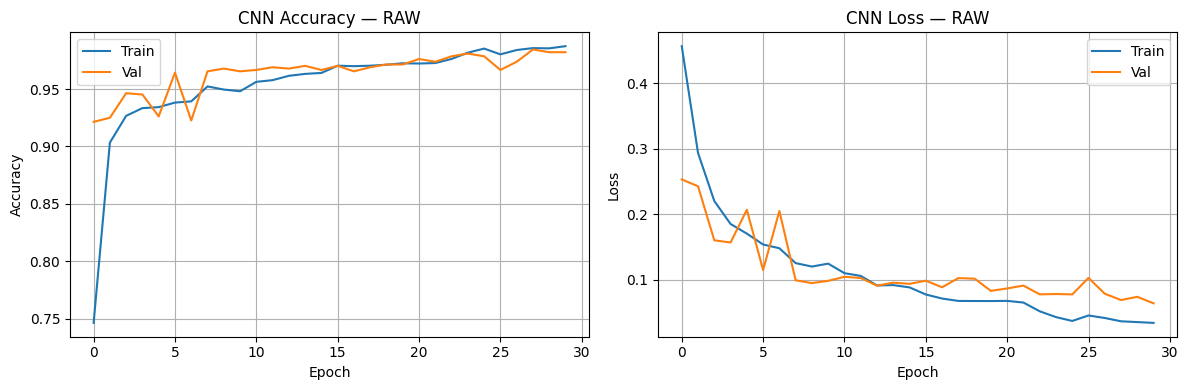

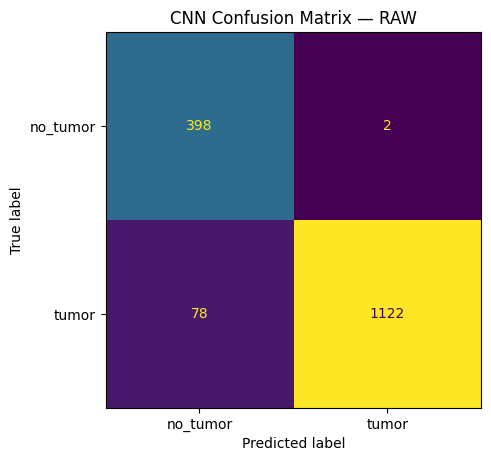

              precision    recall  f1-score   support

    no_tumor       0.84      0.99      0.91       400
       tumor       1.00      0.94      0.97      1200

    accuracy                           0.95      1600
   macro avg       0.92      0.97      0.94      1600
weighted avg       0.96      0.95      0.95      1600

{'accuracy': 0.95, 'precision': 0.998220640569395, 'recall': 0.935, 'f1_score': 0.9655765920826161, 'roc_auc': 0.99293125}
Training CNN on GHE
Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 53s 325ms/step - accuracy: 0.7149 - auc: 0.7838 - loss: 0.5538 - precision: 0.8814 - recall: 0.7162 - val_accuracy: 0.8524 - val_auc: 0.8909 - val_loss: 0.4011 - val_precision: 0.9068 - val_recall: 0.8952
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 49s 329ms/step - accuracy: 0.8391 - auc: 0.8929 - loss: 0.4141 - precision: 0.9200 - recall: 0.8602 - val_accuracy: 0.8952 - val_auc: 0.9509 - val_loss: 0.2678 - val_precision: 0.9343 - val_recall: 0.9254
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 

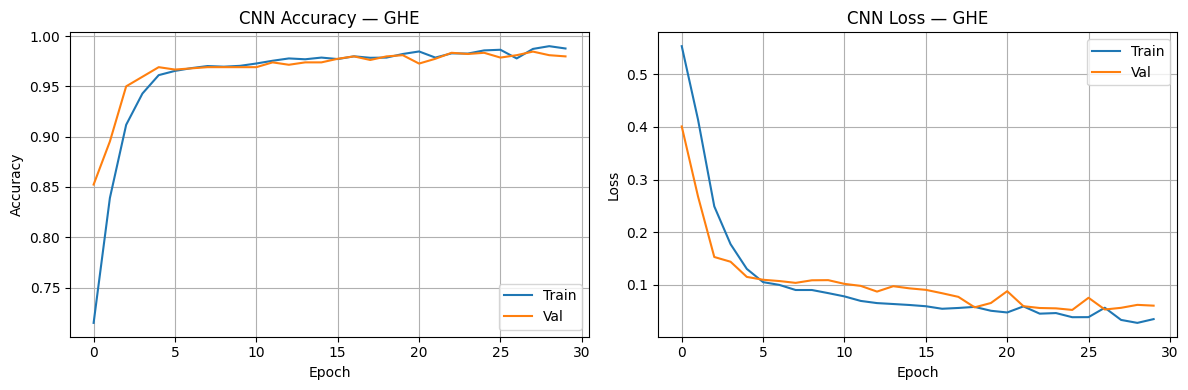

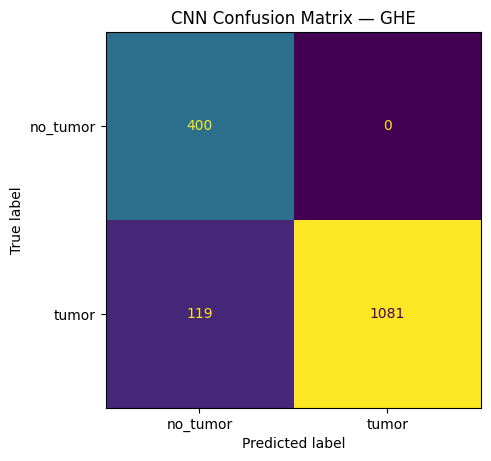

              precision    recall  f1-score   support

    no_tumor       0.77      1.00      0.87       400
       tumor       1.00      0.90      0.95      1200

    accuracy                           0.93      1600
   macro avg       0.89      0.95      0.91      1600
weighted avg       0.94      0.93      0.93      1600

{'accuracy': 0.925625, 'precision': 1.0, 'recall': 0.9008333333333334, 'f1_score': 0.947829899167032, 'roc_auc': 0.9923500000000001}
Training CNN on CLAHE
Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 52s 320ms/step - accuracy: 0.7288 - auc: 0.8145 - loss: 0.5079 - precision: 0.8896 - recall: 0.7289 - val_accuracy: 0.8988 - val_auc: 0.9415 - val_loss: 0.2589 - val_precision: 0.8944 - val_recall: 0.9810
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 45s 305ms/step - accuracy: 0.8742 - auc: 0.9363 - loss: 0.3242 - precision: 0.9404 - recall: 0.8885 - val_accuracy: 0.9190 - val_auc: 0.9760 - val_loss: 0.2487 - val_precision: 0.9828 - val_recall: 0.9079
Epoch 3/30
149/149 ━━━━━━━━━

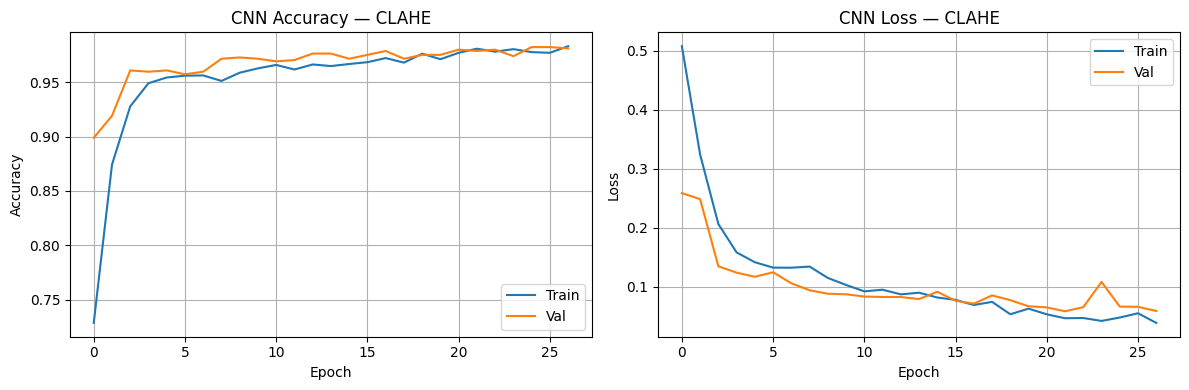

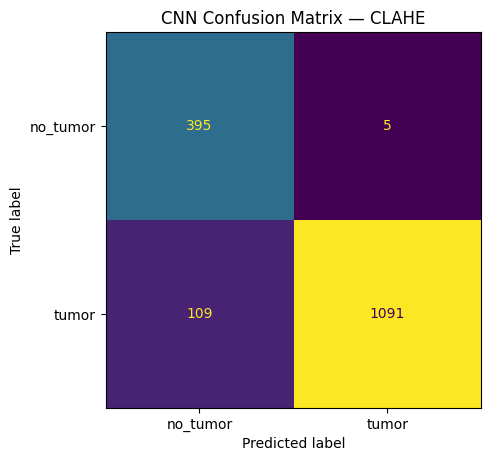

              precision    recall  f1-score   support

    no_tumor       0.78      0.99      0.87       400
       tumor       1.00      0.91      0.95      1200

    accuracy                           0.93      1600
   macro avg       0.89      0.95      0.91      1600
weighted avg       0.94      0.93      0.93      1600

{'accuracy': 0.92875, 'precision': 0.9954379562043796, 'recall': 0.9091666666666667, 'f1_score': 0.9503484320557491, 'roc_auc': 0.9906708333333334}


In [6]:
cnn_results = []
for method in methods:
    print("="*60); print(f"Training CNN on {method.upper()}"); print("="*60)
    tf.keras.backend.clear_session(); tf.random.set_seed(RANDOM_STATE)
    ds = datasets[method]
    model = build_cnn()
    cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    hist = model.fit(ds["X_train"], ds["y_train"],
                     validation_data=(ds["X_val"], ds["y_val"]),
                     epochs=EPOCHS, batch_size=BATCH,
                     class_weight=get_class_weights(ds["y_train"]),
                     callbacks=[cb], verbose=1)
    plot_history(hist, method)
    y_prob = model.predict(ds["X_test"], verbose=0)
    metrics, y_pred = calc_metrics(ds["y_test"], y_prob)
    plot_cm(ds["y_test"], y_pred, method)
    print(classification_report(ds["y_test"], y_pred, target_names=CLASSES, zero_division=0))
    model.save(MODELS_DIR / f"v2_binary_cnn_{method}.keras")
    pd.DataFrame(hist.history).to_csv(
    RESULTS_DIR / f"v2_binary_cnn_{method}_history.csv",
    index=False
    )
    cnn_results.append({"model":"CNN", "preprocessing":method, **metrics})
    print(metrics)

In [7]:
cnn_df = pd.DataFrame(cnn_results)
cnn_df.to_csv(RESULTS_DIR / "v2_binary_cnn_results.csv", index=False)
print(cnn_df.to_string(index=False))

model preprocessing  accuracy  precision   recall  f1_score  roc_auc
  CNN           raw  0.950000   0.998221 0.935000  0.965577 0.992931
  CNN           ghe  0.925625   1.000000 0.900833  0.947830 0.992350
  CNN         clahe  0.928750   0.995438 0.909167  0.950348 0.990671


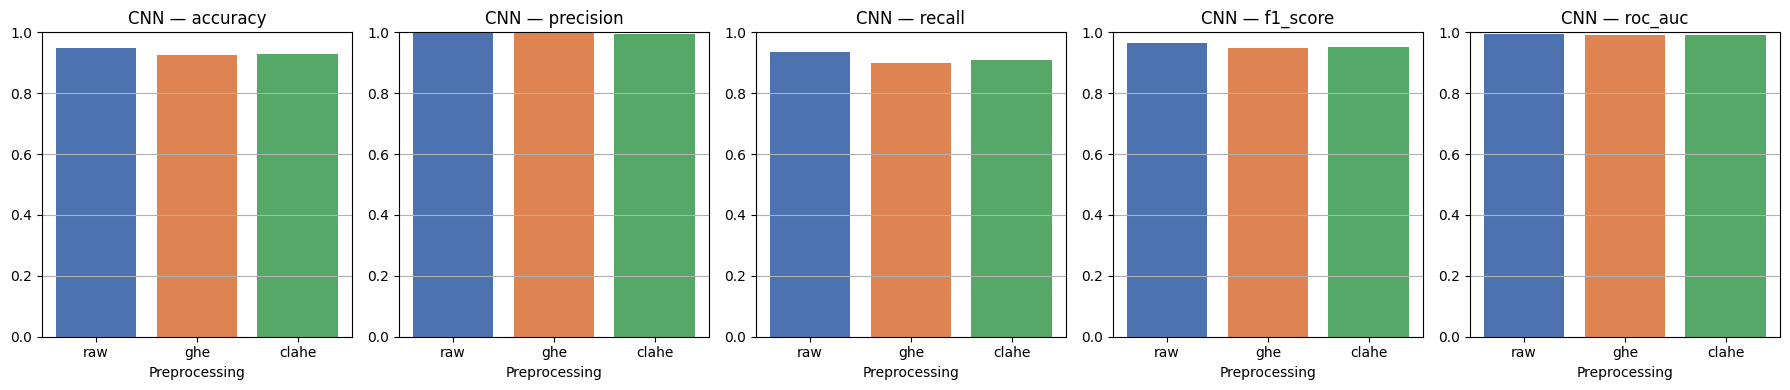

In [8]:
# Bar chart comparison across preprocessing methods
metrics_to_plot = ["accuracy","precision","recall","f1_score","roc_auc"]
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(cnn_df["preprocessing"], cnn_df[metric], color=["#4C72B0","#DD8452","#55A868"])
    ax.set_title(f"CNN — {metric}"); ax.set_ylim(0,1); ax.set_xlabel("Preprocessing"); ax.grid(axis="y")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "v2_binary_cnn_comparison.png", dpi=150)
plt.show()